<a href="https://colab.research.google.com/github/HitenKumar786/Cloud-Computing-Google-Cloud/blob/main/MetroEnergy%20Solutions%20(MES)%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
df = pd.read_csv("/content/MES_Synthetic_Dataset.csv")

df.head()

,Timestamp,Household_ID,Region,Energy_Consumption_kWh,Voltage_V,Current_A,Solar_Generation_kWh,EV_Charging_kWh,Temperature_C,Humidity_Percent,Grid_Load_Percent,Fault_Flag,Maintenance_Status,Electricity_Cost_EUR
0,1/1/2025 0:00,HH_603,North,2.80,235.78,32.00,0.02,2.15,11.85,25.23,82.66,0,Good,0.94
1,1/1/2025 1:00,HH_240,South,5.77,239.28,12.07,0.75,2.82,37.78,65.10,93.70,0,Good,4.85
2,1/1/2025 2:00,HH_183,East,1.52,236.34,20.88,3.78,0.90,27.94,27.79,91.20,0,Good,1.98
3,1/1/2025 3:00,HH_310,West,3.30,235.74,14.20,0.65,1.33,21.94,74.01,52.03,0,Good,4.71
4,1/1/2025 4:00,HH_259,North,4.50,238.61,31.17,5.23,5.30,2.02,61.51,49.54,0,Good,1.91


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               10000 non-null  object 
 1   Household_ID            10000 non-null  object 
 2   Region                  10000 non-null  object 
 3   Energy_Consumption_kWh  10000 non-null  float64
 4   Voltage_V               10000 non-null  float64
 5   Current_A               10000 non-null  float64
 6   Solar_Generation_kWh    10000 non-null  float64
 7   EV_Charging_kWh         10000 non-null  float64
 8   Temperature_C           10000 non-null  float64
 9   Humidity_Percent        10000 non-null  float64
 10  Grid_Load_Percent       10000 non-null  float64
 11  Fault_Flag              10000 non-null  int64  
 12  Maintenance_Status      10000 non-null  object 
 13  Electricity_Cost_EUR    10000 non-null  float64
dtypes: float64(9), int64(1), object(4)
memo

In [7]:
df.describe()

,Energy_Consumption_kWh,Voltage_V,Current_A,Solar_Generation_kWh,EV_Charging_kWh,Temperature_C,Humidity_Percent,Grid_Load_Percent,Fault_Flag,Electricity_Cost_EUR
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.157097,239.950748,20.428909,3.079538,4.112675,17.237167,57.657403,59.813879,0.051500,2.533632
std,1.358011,4.932281,11.327317,1.870012,2.754593,12.943397,21.535605,22.998340,0.221026,1.423727
min,0.200000,221.630000,1.010000,0.000000,0.000000,-5.000000,20.020000,20.030000,0.000000,0.100000
25%,2.177500,236.647500,10.630000,1.680000,1.940000,6.087500,39.170000,39.677500,0.000000,1.290000
50%,3.130000,239.980000,20.295000,3.030000,4.000000,17.160000,57.570000,59.875000,0.000000,2.520000
75%,4.120000,243.300000,30.362500,4.360000,6.020000,28.302500,76.172500,79.532500,0.000000,3.762500
max,7.820000,257.770000,40.000000,8.000000,15.830000,39.990000,94.980000,99.990000,1.000000,5.000000


In [8]:
df.isnull().sum()

,0
Timestamp,0
Household_ID,0
Region,0
Energy_Consumption_kWh,0
Voltage_V,0
Current_A,0
Solar_Generation_kWh,0
EV_Charging_kWh,0
Temperature_C,0
Humidity_Percent,0


In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [14]:
df['Hour'] = df['Timestamp'].dt.hour
df['Day'] = df['Timestamp'].dt.day_name()
df['Month'] = df['Timestamp'].dt.month

In [15]:
#Interactive Energy Consumption Trend
fig = px.line(
    df.iloc[:500],
    x='Timestamp',
    y='Energy_Consumption_kWh',
    title='Energy Consumption Trend'
)

fig.show()


In [ ]:
df = df.dropna()

In [ ]:
df.isnull().sum()

,0
Date,0
Time,0
Global_active_power,0
Global_reactive_power,0
Voltage,0
Global_intensity,0
Sub_metering_1,0
Sub_metering_2,0
Sub_metering_3,0


In [21]:
# Hourly Consumption Analysis
hourly_avg = (
    df.groupby('Hour')['Energy_Consumption_kWh']
      .mean()
      .reset_index()
)

fig = px.bar(
    hourly_avg,
    x='Hour',
    y='Energy_Consumption_kWh',
    title='Average Energy Consumption by Hour',
    color_discrete_sequence=['purple']
)

fig.show()

In [27]:
#EV Charging Analysis
fig = px.scatter(
    df.sample(3000),
    x='EV_Charging_kWh',
    y='Energy_Consumption_kWh',
    title='EV Charging vs Energy Consumption',
    color_discrete_sequence=['brown']

)

fig.show()

In [28]:
#Solar Generation Analysis
fig = px.scatter(
    df.sample(3000),
    x='Solar_Generation_kWh',
    y='Energy_Consumption_kWh',
    title='Solar Generation vs Energy Consumption'
)

fig.show()

In [33]:
# Corealtion Heatmap
cols = [
    'Energy_Consumption_kWh',
    'Voltage_V',
    'Current_A',
    'Solar_Generation_kWh',
    'EV_Charging_kWh',
    'Temperature_C',
    'Grid_Load_Percent'
]

corr = df[cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    title='Correlation Heatmap'
)

fig.update_layout(
    width=1000,
    height=800,
    title_x=0.4
)

fig.show()

In [37]:
#Fault Analysis

fault_counts = (
    df['Fault_Flag']
      .replace({0: 'No Fault', 1: 'Fault'})
      .value_counts()
      .reset_index()
)

fault_counts.columns = ['Status', 'Count']

fig = px.pie(
    fault_counts,
    names='Status',
    values='Count',
    title='Fault Distribution',
    hole=0.4
)

fig.update_traces(
    textinfo='percent+label'
)

fig.show()

In [38]:
# Machine Learning Forecasting

features = [
    'Voltage_V',
    'Current_A',
    'Solar_Generation_kWh',
    'EV_Charging_kWh',
    'Temperature_C',
    'Grid_Load_Percent'
]

In [39]:
# Train Model

X = df[features]

y = df['Energy_Consumption_kWh']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

predictions = model.predict(X_test)

In [40]:
# Model Evaluation

print("MAE:", mean_absolute_error(y_test, predictions))

print("RMSE:",
      np.sqrt(mean_squared_error(y_test, predictions)))

print("R2 Score:",
      r2_score(y_test, predictions))

MAE: 0.9056466692631591
RMSE: 1.0521585363814634
R2 Score: 0.4263358719408825


In [41]:
# Actual vs Predicted

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        y=y_test.values[:100],
        name='Actual'
    )
)

fig.add_trace(
    go.Scatter(
        y=predictions[:100],
        name='Predicted'
    )
)

fig.update_layout(
    title='Actual vs Predicted Energy Consumption'
)

fig.show()

In [ ]:
sample = df.sample(5000, random_state=42)

fig = px.scatter(
    sample,
    x='Voltage',
    y='Global_active_power',
    title='Voltage vs Power Consumption',
    opacity=0.6
)

fig.show()

In [ ]:
import plotly.express as px

cols = [
    'Global_active_power',
    'Global_reactive_power',
    'Voltage',
    'Global_intensity',
    'Sub_metering_1',
    'Sub_metering_2',
    'Sub_metering_3'
]

corr = df[cols].corr()

fig = px.imshow(
    corr,
    text_auto=".2f",
    title='Interactive Correlation Heatmap',
    aspect="auto"
)

fig.update_layout(
    width=1200,
    height=900,
    title_x=0.5,
    font=dict(size=14)
)

fig.show()

In [ ]:
# Create Forecasting Dataset

df['Hour'] = df['Datetime'].dt.hour
df[['Hour','Global_active_power']].head()

,Hour,Global_active_power
0,17,4.216
1,17,5.360
2,17,5.374
3,17,5.388
4,17,3.666


In [ ]:
# Train Forecasting Model
X = df[['Hour']]
y = df['Global_active_power']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [ ]:
predictions = model.predict(X_test)

In [ ]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE =", mae)

MAE = 0.8120328368275737


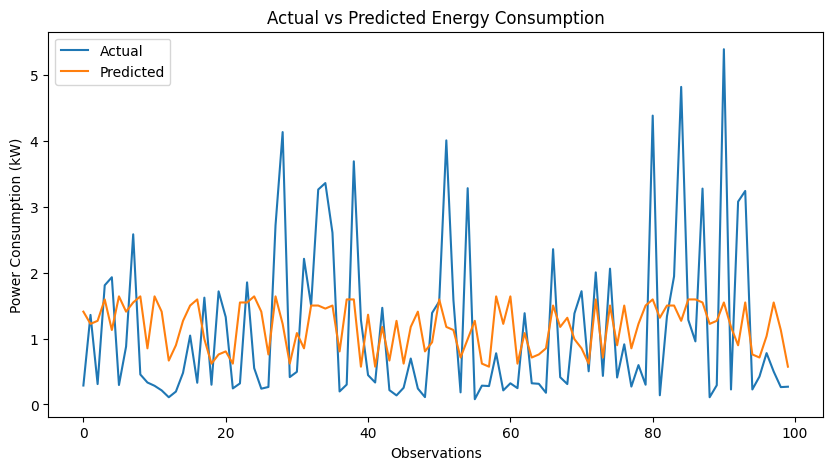

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test.values[:100],
    label='Actual'
)

plt.plot(
    predictions[:100],
    label='Predicted'
)

plt.legend()

plt.title("Actual vs Predicted Energy Consumption"),
plt.xlabel("Observations"),
plt.ylabel("Power Consumption (kW)")


plt.show()